# MAD Dataset Preprocessing Pipeline for ALM

This notebook preprocesses the **Military Audio Dataset (MAD)** into a
standardized format for the ALM audio encoder, following the same pipeline
structure and style as the existing ALM ESC-50 / UrbanSound8K preprocessing
notebook.

### Pipeline Summary
| Step | Operation |
|------|----------|
| 1 | Load audio |
| 2 | Convert to Mono |
| 3 | Resample to 16,000 Hz |
| 4 | Pad to 10 seconds (never trim) |
| 5 | Save with unified naming `alm_mad_XXXXXX.wav` |
| 6 | Update `metadata.csv` |

**Scope of this notebook — data exploration + preprocessing validation only.**
It does **not** train a model, modify `audio_dataset.py`, or touch any other
project notebook.

---

## 1. Setup & Imports

In [1]:
import os
import sys
import warnings
import random
from pathlib import Path
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display

import soundfile as sf
HAS_SOUNDFILE = True

from tqdm import tqdm


warnings.filterwarnings("ignore")


RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Imports OK")
print(f"librosa      : {librosa.__version__}")
print(f"soundfile    : {'available' if HAS_SOUNDFILE else 'NOT available (falling back to librosa)'}")
print(f"random seed  : {RANDOM_STATE}")

Imports OK
librosa      : 0.11.0
soundfile    : available
random seed  : 42


In [2]:
# %% Plotting configuration (consistent with existing ALM notebooks)
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor": "#0f1117",
    "savefig.facecolor": "#0f1117",
    "axes.edgecolor": "#3a3f4b",
    "axes.labelcolor": "#e6e6e6",
    "text.color": "#e6e6e6",
    "xtick.color": "#c9c9c9",
    "ytick.color": "#c9c9c9",
    "axes.grid": True,
    "grid.color": "#2a2e38",
    "grid.alpha": 0.5,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 110,
})

ALM_ACCENT = "#4fc3f7"
ALM_ACCENT_2 = "#ff8a65"
ALM_ACCENT_3 = "#81c784"
ALM_WARN = "#e57373"

print("Plotting style configured (dark ALM theme).")

Plotting style configured (dark ALM theme).


---

## 2. Project Path Detection

This notebook lives in `ALM/script/`. Path handling below is robust to being
launched either from `ALM/script/` (the normal case) or from the project
root `ALM/`, and does not depend on any variable from another notebook.

The project root is identified as the closest ancestor directory containing
`data/`, `models/`, `outputs/`, and `script/`. MAD is then searched for in a
short list of conventional locations under `data/`.

In [3]:
_cwd = Path.cwd()
ROOT = _cwd.parent
OUTPUT_DIR = ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("============================================================")
print("PROJECT PATHS")
print("============================================================")
print(f"Working directory : {_cwd}")
print(f"Project root       : {ROOT}")
print(f"Outputs directory  : {OUTPUT_DIR}")
print(f"Figures directory  : {FIGURES_DIR}")
print("============================================================")

PROJECT PATHS
Working directory : c:\Users\PRAYAG\Desktop\ALM\alm\script
Project root       : c:\Users\PRAYAG\Desktop\ALM\alm
Outputs directory  : c:\Users\PRAYAG\Desktop\ALM\alm\outputs
Figures directory  : c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures


In [4]:
MAD_DIR = ROOT / 'data' / 'raw' / 'MAD_dataset'
print(MAD_DIR)

c:\Users\PRAYAG\Desktop\ALM\alm\data\raw\MAD_dataset


In [5]:
print((MAD_DIR / "training.csv").exists())
print((MAD_DIR / "test.csv").exists())

True
True


---

## 3. Preprocessing Configuration

### Why 10 seconds?

MAD contains recordings shorter than 10 seconds as well as recordings close
to 10 seconds. Using the existing ALM 5-second target would discard
temporal information from the longer recordings. Therefore, **the ALM
preprocessing target for MAD is extended to 10 seconds**. Shorter
recordings are zero-padded, while recordings at the target length are
preserved without modification. **No audio is intentionally trimmed.**

Everything else (sample rate, mel bins, FFT size, hop length) is kept
identical to the existing ALM audio encoder pipeline so the rest of the
pipeline stays compatible.

In [ ]:
TARGET_SR   = 16_000     # Hz
TARGET_DUR  = 10.0       # seconds  (existing ALM pipeline uses 5.0 — intentionally changed for MAD)

N_FFT       = 1024
HOP_LENGTH  = 512
N_MELS      = 128

TARGET_SAMPLES = int(TARGET_SR * TARGET_DUR)

# Audio-file scanning configuration
FULL_SCAN = False
SAMPLE_N  = 150

MAD_CLASS_NAMES = {
    0: "Communication",
    1: "Gunshot",
    2: "Footsteps",
    3: "Shelling",
    4: "Vehicle",
    5: "Helicopter",
    6: "Fighter",
}

print("=" * 60)
print("MAD / ALM PREPROCESSING CONFIGURATION")
print("=" * 60)
print(f"Target sample rate : {TARGET_SR} Hz")
print(f"Target duration    : {TARGET_DUR} seconds")
print(f"Target samples     : {TARGET_SAMPLES}")
print(f"Mel bins           : {N_MELS}")
print(f"FFT size           : {N_FFT}")
print(f"Hop length          : {HOP_LENGTH}")
print(f"Trimming           : DISABLED")
print(f"Padding            : ZERO PADDING")
print("=" * 60)

MAD / ALM PREPROCESSING CONFIGURATION
Target sample rate : 16000 Hz
Target duration    : 10.0 seconds
Target samples     : 160000
Mel bins           : 128
FFT size           : 1024
Hop length          : 512
Trimming           : DISABLED
Padding            : ZERO PADDING


---

## 4. Output Paths & Directory Structure

Mirrors the existing ALM preprocessing notebook: processed audio is written
to `data/processed_mad/audio/` with unified `alm_mad_XXXXXX.wav` naming, and a
single `metadata.csv` records every processed sample.

In [7]:
PROCESSED_DIR  = ROOT / "data" / "processed_mad"
AUDIO_OUT_DIR  = PROCESSED_DIR / "audio"
METADATA_PATH  = PROCESSED_DIR / "metadata.csv"

print(f"Target SR       : {TARGET_SR} Hz")
print(f"Target Duration : {TARGET_DUR} s  ({TARGET_SAMPLES} samples)")
print(f"Output dir      : {AUDIO_OUT_DIR}")
print(f"Metadata path   : {METADATA_PATH}")

Target SR       : 16000 Hz
Target Duration : 10.0 s  (160000 samples)
Output dir      : c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\audio
Metadata path   : c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\metadata.csv


In [8]:
def create_directory_structure():
    """
    Creates the processed-data output directories.
    MAD_DIR (raw data) is expected to already exist and is not created here.
    """
    dirs = [AUDIO_OUT_DIR, PROCESSED_DIR, FIGURES_DIR]
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        print(f"  [dir] {d}")
    print("\nDirectory structure ready.")


create_directory_structure()

  [dir] c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\audio
  [dir] c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad
  [dir] c:\Users\PRAYAG\Desktop\ALM\alm\outputs\figures

Directory structure ready.


---

## 5. Core Audio Processing Functions

Same shape as the existing ALM pipeline (`load_audio` -> `convert_to_mono`
-> `resample_audio` -> pad/trim -> `save_audio`), with one deliberate
difference: `pad_never_trim` **only pads**. If a clip is longer than the
10-second target it raises instead of silently cutting audio — see Section
9 for how this is handled inside the pipeline run.

In [9]:
def load_audio(filepath: Path) -> tuple:
    """
    Load an audio file using librosa.
    Returns (waveform, original_sample_rate).
    """
    waveform, sr = librosa.load(str(filepath), sr=None, mono=False)
    return waveform, sr


def convert_to_mono(waveform: np.ndarray) -> np.ndarray:
    """
    Convert stereo (or multi-channel) waveform to mono by averaging channels.
    Shape: (channels, samples) -> (samples,)
    """
    if waveform.ndim > 1:
        waveform = waveform.mean(axis=0)
    return waveform


def resample_audio(waveform: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    """
    Resample waveform from orig_sr to target_sr using librosa (high-quality resampling).
    """
    if orig_sr == target_sr:
        return waveform
    return librosa.resample(waveform, orig_sr=orig_sr, target_sr=target_sr)


def pad_never_trim(waveform: np.ndarray, target_samples: int) -> np.ndarray:
    """
    Zero-pad short clips to target_samples. NEVER trims.

    Raises ValueError if the waveform is longer than target_samples — MAD
    audio is not sped up, time-stretched, or silently cut.
    """
    current_len = len(waveform)
    if current_len < target_samples:
        padding = target_samples - current_len
        waveform = np.pad(waveform, (0, padding), mode="constant")
    elif current_len > target_samples:
        raise ValueError(
            f"Clip has {current_len} samples, exceeds target of {target_samples} "
            f"({current_len / TARGET_SR:.2f}s > {TARGET_DUR:.1f}s). Not trimmed."
        )
    return waveform


def preprocess_audio(filepath: Path) -> np.ndarray:
    """
    Full preprocessing pipeline for a single audio file.
    Returns standardized waveform ready for saving. Raises ValueError for
    clips longer than TARGET_DUR (caller is responsible for catching this
    and logging it as an anomaly rather than trimming).
    """
    waveform, sr = load_audio(filepath)                    # Step 1: Load
    waveform = convert_to_mono(waveform)                    # Step 2: Mono
    waveform = resample_audio(waveform, sr, TARGET_SR)      # Step 3: Resample
    waveform = pad_never_trim(waveform, TARGET_SAMPLES)     # Step 4: Pad (never trim)
    return waveform


def save_audio(waveform: np.ndarray, out_path: Path):
    """
    Save waveform as a 16-bit PCM WAV file.
    """
    sf.write(str(out_path), waveform, TARGET_SR, subtype="PCM_16")


print("Audio processing functions defined.")

Audio processing functions defined.


---

## 6. Dataset Loader Functions

Parses `training.csv` and `test.csv` into a single manifest. MAD labels are
numeric class IDs only — no class names are invented. The `split` field
(`training` / `test`) already comes from the CSV, so it is used as-is
rather than reassigning random folds.

In [10]:
def load_mad_manifest() -> list:
    """
    Parse training.csv and test.csv and return a combined sample manifest.

    MAD CSV columns: path, label, youtube title, youtube url
    `path` is already relative to MAD_DIR (e.g. training/<video_id>/<clip>.wav).
    """
    train_csv = MAD_DIR / "training.csv"
    test_csv = MAD_DIR / "test.csv"

    if not train_csv.exists() or not test_csv.exists():
        raise FileNotFoundError(
            f"Expected 'training.csv' and 'test.csv' inside: {MAD_DIR}"
        )

    manifest = []
    for csv_path, split_name in [(train_csv, "training"), (test_csv, "test")]:
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]
        for _, row in df.iterrows():
            audio_path = MAD_DIR / row["path"]
            if audio_path.exists():
                manifest.append({
                    "filepath": audio_path,
                    "label": row["label"],
                    "split": split_name,
                    "source_file": row["path"],
                })
            else:
                print(f"  [missing] {audio_path}")

    print(f"MAD -> {len(manifest)} samples found.")
    return manifest


print("Dataset manifest function defined.")

Dataset manifest function defined.


---

## 7. Main Preprocessing Pipeline

Same shape as `run_preprocessing_pipeline` in the existing ALM notebook.
Clips that exceed the 10-second target raise inside `preprocess_audio` —
those are caught here, logged as **anomalies** (not silently trimmed), and
excluded from the saved output rather than corrupted.

In [11]:
def run_preprocessing_pipeline(manifest: list, start_id: int = 1) -> tuple:
    """
    Process all samples in manifest and return (metadata_df, anomalies_df).

    Args:
        manifest   : list of sample dicts from load_mad_manifest()
        start_id   : starting sequential ID for alm_mad_XXXXXX.wav naming

    Returns:
        metadata_df  : DataFrame of successfully processed samples
        anomalies_df : DataFrame of clips longer than TARGET_DUR (not trimmed, not saved)
    """
    records = []
    errors = []
    anomalies = []
    current_id = start_id

    for sample in tqdm(manifest, desc="Processing audio"):
        try:
            waveform, orig_sr = load_audio(sample["filepath"])
            orig_duration = (waveform.shape[-1] if waveform.ndim == 1 else waveform.shape[-1]) / orig_sr

            waveform = preprocess_audio(sample["filepath"])

            out_filename = f"alm_mad_{current_id:06d}.wav"
            out_path = AUDIO_OUT_DIR / out_filename
            save_audio(waveform, out_path)

            records.append({
                "id": current_id,
                "file": out_filename,
                "label": sample["label"],
                "label_name" :MAD_CLASS_NAMES.get(sample['label'] , f"Class {sample['label']}"),
                "split": sample["split"],
                "duration_original": orig_duration,
                "duration_processed": TARGET_DUR,
                "source_file": sample["source_file"],
            })
            current_id += 1

        except ValueError as e:
            # Clip longer than target duration — logged, NOT trimmed, NOT saved.
            anomalies.append({"file": sample["source_file"], "reason": str(e)})
        except Exception as e:
            errors.append({"file": str(sample["filepath"]), "error": str(e)})

    if errors:
        print(f"\n{len(errors)} files failed to process:")
        for err in errors[:10]:
            print(f"   {err['file']} -> {err['error']}")

    if anomalies:
        print(f"\n{len(anomalies)} file(s) exceeded {TARGET_DUR}s and were NOT trimmed or saved:")
        for a in anomalies[:10]:
            print(f"   {a['file']} -> {a['reason']}")

    metadata_df = pd.DataFrame(records)
    anomalies_df = pd.DataFrame(anomalies)
    return metadata_df, anomalies_df


print("Pipeline function defined.")

Pipeline function defined.


---

## 8. Run the Full Pipeline

> Make sure `MAD_DIR` (Section 2) points at a folder containing
> `training.csv`, `test.csv`, `training/`, and `test/` before running this
> cell.

In [12]:
print("=" * 60)
print(" MAD PREPROCESSING PIPELINE")
print("=" * 60)

print("\nLoading dataset manifest...")
mad_manifest = load_mad_manifest()
print(f"\nTotal samples to process: {len(mad_manifest)}")

print("\nRunning preprocessing pipeline...")
metadata_df, anomalies_df = run_preprocessing_pipeline(mad_manifest, start_id=1)

metadata_df.to_csv(METADATA_PATH, index=False)
print(f"\nMetadata saved -> {METADATA_PATH}")

print("\n" + "=" * 60)
print(f"DONE!  {len(metadata_df)} samples processed successfully.")
print(f"       {len(anomalies_df)} sample(s) flagged as anomalies (not trimmed, not saved).")
print(f"   Audio files : {AUDIO_OUT_DIR}")
print(f"   Metadata    : {METADATA_PATH}")
print("=" * 60)

 MAD PREPROCESSING PIPELINE

Loading dataset manifest...
MAD -> 7466 samples found.

Total samples to process: 7466

Running preprocessing pipeline...


Processing audio: 100%|██████████| 7466/7466 [01:30<00:00, 82.80it/s] 



Metadata saved -> c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\metadata.csv

DONE!  7466 samples processed successfully.
       0 sample(s) flagged as anomalies (not trimmed, not saved).
   Audio files : c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\audio
   Metadata    : c:\Users\PRAYAG\Desktop\ALM\alm\data\processed_mad\metadata.csv


---

## 9. Verify Output

In [13]:
df = pd.read_csv(METADATA_PATH)

print(f"Total samples : {len(df)}")
print(f"Columns       : {list(df.columns)}")
print(f"Unique labels : {df['label'].nunique()}")
print(f"Splits        : {df['split'].value_counts().to_dict()}")
print(f"All 10.0s?    : {(df['duration_processed'] == TARGET_DUR).all()}")
print()
df.head(10)

Total samples : 7466
Columns       : ['id', 'file', 'label', 'label_name', 'split', 'duration_original', 'duration_processed', 'source_file']
Unique labels : 7
Splits        : {'training': 6429, 'test': 1037}
All 10.0s?    : True



,id,file,label,label_name,split,duration_original,duration_processed,source_file
0,1,alm_mad_000001.wav,3,Shelling,training,2.000,10.0,training/398/0.wav
1,2,alm_mad_000002.wav,3,Shelling,training,3.000,10.0,training/398/1.wav
2,3,alm_mad_000003.wav,3,Shelling,training,2.000,10.0,training/398/2.wav
3,4,alm_mad_000004.wav,3,Shelling,training,3.000,10.0,training/398/3.wav
4,5,alm_mad_000005.wav,3,Shelling,training,3.000,10.0,training/398/4.wav
5,6,alm_mad_000006.wav,3,Shelling,training,9.000,10.0,training/398/5.wav
6,7,alm_mad_000007.wav,4,Vehicle,training,6.000,10.0,training/398/6.wav
7,8,alm_mad_000008.wav,4,Vehicle,training,6.000,10.0,training/398/7.wav
8,9,alm_mad_000009.wav,4,Vehicle,training,3.000,10.0,training/398/8.wav
9,10,alm_mad_000010.wav,0,Communication,training,4.017,10.0,training/088/0.wav


In [14]:
# Split distribution
print("Split distribution:")
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))

Split distribution:
label       0     1    2    3    4    5    6
split                                       
test      207   280  104  104  122   91  129
training  774  1293  773  883  910  934  862


In [15]:
# Verify a random processed audio file
sample_row = df.sample(1).iloc[0]
sample_path = AUDIO_OUT_DIR / sample_row["file"]

waveform, sr = sf.read(str(sample_path))

print(f"File         : {sample_row['file']}")
print(f"Label        : Class {int(sample_row['label'])}")
print(f"Split        : {sample_row['split']}")
print(f"Sample rate  : {sr} Hz  (expected: {TARGET_SR})")
print(f"Num samples  : {len(waveform)}  (expected: {TARGET_SAMPLES})")
print(f"Duration     : {len(waveform)/sr:.2f}s  (expected: {TARGET_DUR}s)")
print(f"Shape        : {waveform.shape}")

assert sr == TARGET_SR,                 f"SR mismatch: {sr} != {TARGET_SR}"
assert len(waveform) == TARGET_SAMPLES, f"Length mismatch: {len(waveform)} != {TARGET_SAMPLES}"
assert waveform.ndim == 1,              f"Not mono: ndim = {waveform.ndim}"

print("\nAll assertions passed — audio file is correctly preprocessed.")

File         : alm_mad_002277.wav
Label        : Class 4
Split        : training
Sample rate  : 16000 Hz  (expected: 16000)
Num samples  : 160000  (expected: 160000)
Duration     : 10.00s  (expected: 10.0s)
Shape        : (160000,)

All assertions passed — audio file is correctly preprocessed.


In [16]:
# 10-second padding verification — proves no original samples were lost
short_row = df.loc[df["duration_original"].idxmin()]
near_target_row = df.loc[(df["duration_original"] - TARGET_DUR).abs().idxmin()]

def report_padding(row, label):
    orig_samples = int(round(row["duration_original"] * TARGET_SR))
    padded_samples = max(TARGET_SAMPLES - orig_samples, 0)
    print("=" * 60)
    print(f"10-SECOND PADDING VERIFICATION — {label}")
    print("=" * 60)
    print(f"File               : {row['source_file']}")
    print(f"Original duration  : {row['duration_original']:.2f} s")
    print(f"Target duration    : {TARGET_DUR:.2f} s")
    print()
    print(f"Original samples   : {orig_samples}")
    print(f"Padded samples     : {padded_samples}")
    print(f"Final samples      : {TARGET_SAMPLES}")
    print()
    print("Data removed       : 0 samples")
    print("Data retained      : 100%")
    print("=" * 60)
    print()

report_padding(short_row, "SHORTEST CLIP")
report_padding(near_target_row, "NEAR-TARGET CLIP")

if len(anomalies_df) == 0:
    print("No MAD audio files required trimming.")
else:
    print(f"{len(anomalies_df)} file(s) exceeded {TARGET_DUR}s and were excluded (not trimmed):")
    print(anomalies_df)

10-SECOND PADDING VERIFICATION — SHORTEST CLIP
File               : training/219/0.wav
Original duration  : 1.00 s
Target duration    : 10.00 s

Original samples   : 16000
Padded samples     : 144000
Final samples      : 160000

Data removed       : 0 samples
Data retained      : 100%

10-SECOND PADDING VERIFICATION — NEAR-TARGET CLIP
File               : training/088/9.wav
Original duration  : 10.00 s
Target duration    : 10.00 s

Original samples   : 160000
Padded samples     : 0
Final samples      : 160000

Data removed       : 0 samples
Data retained      : 100%

No MAD audio files required trimming.


---

## 10. Dataset Statistics (Post-Processing)

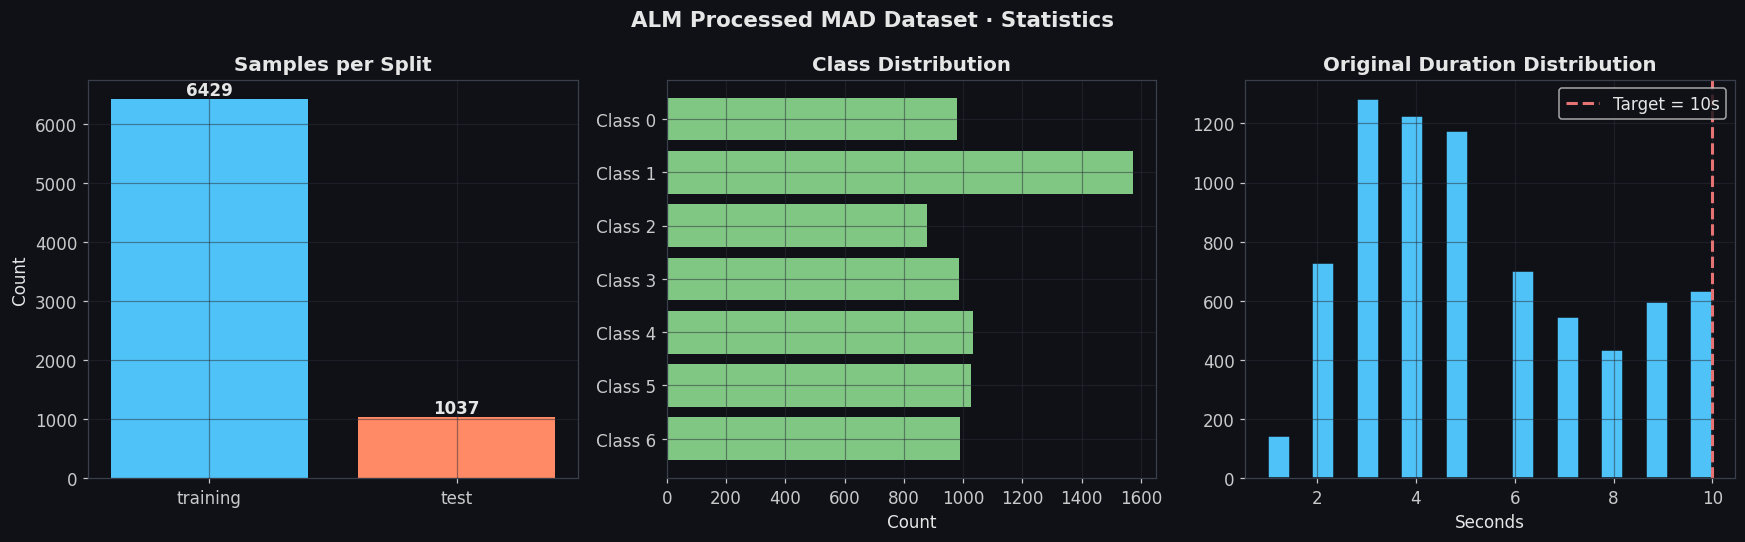

Statistics plot saved.


In [17]:
df = pd.read_csv(METADATA_PATH)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("ALM Processed MAD Dataset \u00b7 Statistics", fontsize=14, fontweight="bold")

# 1. Samples per split
counts = df["split"].value_counts()
axes[0].bar(counts.index, counts.values, color=[ALM_ACCENT, ALM_ACCENT_2])
axes[0].set_title("Samples per Split")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.01, str(v), ha="center", fontweight="bold")

# 2. Label distribution
label_counts = df["label"].value_counts().sort_index()
label_names = [f"Class {int(l)}" for l in label_counts.index]
axes[1].barh(label_names[::-1], label_counts.values[::-1], color=ALM_ACCENT_3)
axes[1].set_title("Class Distribution")
axes[1].set_xlabel("Count")

# 3. Original duration distribution
axes[2].hist(df["duration_original"], bins=20, color=ALM_ACCENT, edgecolor="#0f1117")
axes[2].axvline(TARGET_DUR, color=ALM_WARN, linestyle="--", linewidth=2, label=f"Target = {TARGET_DUR:.0f}s")
axes[2].set_title("Original Duration Distribution")
axes[2].set_xlabel("Seconds")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "mad_dataset_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Statistics plot saved.")

---

## 11. PyTorch Dataset Class

Ready-to-use `ALMMadDataset` for use in training scripts, mirroring the
existing `ALMDataset` shape. Uses the `split` column already present in the
metadata (no invented fold assignment).

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader


class ALMMadDataset(Dataset):
    """
    PyTorch Dataset for the ALM-processed MAD audio dataset.

    Args:
        metadata_path : path to metadata.csv
        audio_dir     : path to processed/audio/ folder
        split         : "training" or "test" (matches MAD's own split, no invented folds)
        transform     : optional transform applied to waveform tensor

    Returns per item:
        waveform      : torch.Tensor of shape (1, TARGET_SAMPLES) — (channels, samples)
        label_idx     : int — class index
        meta          : dict — id, file, label, split
    """

    def __init__(self, metadata_path, audio_dir, split=None, transform=None):
        self.audio_dir = Path(audio_dir)
        self.transform = transform

        df = pd.read_csv(metadata_path)
        if split is not None:
            df = df[df["split"] == split].reset_index(drop=True)
        self.df = df

        self.labels = sorted(df["label"].unique().tolist())
        self.label2idx = {lbl: idx for idx, lbl in enumerate(self.labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filepath = self.audio_dir / row["file"]

        waveform, _ = sf.read(str(filepath), dtype="float32")
        waveform = torch.from_numpy(waveform).unsqueeze(0)  # (1, samples)

        if self.transform:
            waveform = self.transform(waveform)

        label_idx = self.label2idx[row["label"]]
        meta = {
            "id": row["id"],
            "file": row["file"],
            "label": row["label"],
            "split": row["split"],
        }
        return waveform, label_idx, meta


# Quick smoke-test
train_ds = ALMMadDataset(METADATA_PATH, AUDIO_OUT_DIR, split="training")
test_ds = ALMMadDataset(METADATA_PATH, AUDIO_OUT_DIR, split="test")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

waveforms, labels, metas = next(iter(train_loader))

print(f"Train samples : {len(train_ds)}")
print(f"Test  samples : {len(test_ds)}")
print(f"Num classes   : {len(train_ds.labels)}")
print(f"Waveform shape: {waveforms.shape}  (batch, channels, samples)")
print(f"Labels shape  : {labels.shape}")
print(f"Sample labels : {[train_ds.labels[l] for l in labels[:5].tolist()]}")
print("\nALMMadDataset is working correctly!")

Train samples : 6429
Test  samples : 1037
Num classes   : 7
Waveform shape: torch.Size([16, 1, 160000])  (batch, channels, samples)
Labels shape  : torch.Size([16])
Sample labels : [0, 6, 5, 2, 1]

ALMMadDataset is working correctly!


---

## 12. Final Directory Tree

In [20]:
def print_tree(root: Path, max_files: int = 5, indent: str = ""):
    """Print a compact directory tree."""
    items = sorted(root.iterdir()) if root.is_dir() else []
    files = [i for i in items if i.is_file()]
    dirs = [i for i in items if i.is_dir()]

    for d in dirs:
        print(f"{indent}[dir] {d.name}/")
        print_tree(d, max_files, indent + "   ")

    shown = files[:max_files]
    for f in shown:
        size_kb = f.stat().st_size / 1024
        print(f"{indent}[file] {f.name}  ({size_kb:.1f} KB)")
    if len(files) > max_files:
        print(f"{indent}   ... and {len(files) - max_files} more files")


print(f"[dir] {ROOT}/")
print_tree(ROOT / "data" / "processed_mad")

[dir] c:\Users\PRAYAG\Desktop\ALM\alm/
[dir] audio/
   [file] alm_mad_000001.wav  (312.5 KB)
   [file] alm_mad_000002.wav  (312.5 KB)
   [file] alm_mad_000003.wav  (312.5 KB)
   [file] alm_mad_000004.wav  (312.5 KB)
   [file] alm_mad_000005.wav  (312.5 KB)
      ... and 7461 more files
[file] metadata.csv  (542.3 KB)


---
## Pipeline Complete

| Output | Description |
|--------|------------|
| `data/processed/audio/alm_mad_*.wav` | Standardized WAV files: mono, 16kHz, 10s, zero-padded |
| `data/processed/metadata.csv` | Full metadata with id, label, split, duration, source |
| `outputs/figures/mad_dataset_statistics.png` | Visual summary of the processed dataset |

### Duration Policy

The MAD adaptation uses a **10-second fixed input window**.

- Clips shorter than 10 seconds are zero-padded.
- Clips exactly 10 seconds are preserved.
- Clips longer than 10 seconds are **not** silently trimmed — they are
  logged as anomalies and excluded from the saved output for manual review.

### Training Split Example
```python
train_ds = ALMMadDataset(METADATA_PATH, AUDIO_OUT_DIR, split="training")
test_ds  = ALMMadDataset(METADATA_PATH, AUDIO_OUT_DIR, split="test")
```